In [ ]:
# Day32_Recommendation_systems
17-apr-25

# A.user item similarity

# Step 1 - Define the problem

# Step 2 - Collect and Prepare Data(EDA)

## Step 2.1 - Understand the Dataset                                                      

In [72]:
import pandas as pd 
import matplotlib.pyplot as plt
movies= pd.read_csv('Movie.csv')

In [10]:
movies.head()

,userId,movie,rating
0,3,Toy Story (1995),4.0
1,6,Toy Story (1995),5.0
2,8,Toy Story (1995),4.0
3,10,Toy Story (1995),4.0
4,11,Toy Story (1995),4.5


In [14]:
movies.shape


(8992, 3)

In [18]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8992 entries, 0 to 8991
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   userId  8992 non-null   int64  
 1   movie   8992 non-null   object 
 2   rating  8992 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 210.9+ KB


In [20]:
movies.describe()

,userId,rating
count,8992.000000,8992.000000
mean,3521.880116,3.557162
std,2012.497384,0.967071
min,1.000000,0.500000
25%,1779.000000,3.000000
50%,3530.000000,3.500000
75%,5213.250000,4.000000
max,7120.000000,5.000000


In [24]:
movies.isnull()

,userId,movie,rating
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
8987,False,False,False
8988,False,False,False
8989,False,False,False
8990,False,False,False


In [26]:
movies.isnull().sum()

userId    0
movie     0
rating    0
dtype: int64

In [34]:
movies['movie'].unique()

array(['Toy Story (1995)', 'Jumanji (1995)', 'Grumpier Old Men (1995)',
       'Waiting to Exhale (1995)', 'Father of the Bride Part II (1995)',
       'Heat (1995)', 'Sabrina (1995)', 'Tom and Huck (1995)',
       'Sudden Death (1995)', 'GoldenEye (1995)'], dtype=object)

In [36]:
movies['movie'].nunique()

10

In [42]:
movies['userId'].nunique()

4081

In [46]:
movies['rating'].nunique()

10

In [48]:
movies['rating'].unique()

array([4. , 5. , 4.5, 3. , 1. , 3.5, 1.5, 2. , 2.5, 0.5])

In [50]:
pd.DataFrame(movies['rating'].unique())

,0
0,4.0
1,5.0
2,4.5
3,3.0
4,1.0
5,3.5
6,1.5
7,2.0
8,2.5
9,0.5


In [54]:
movies['movie'].value_counts()

movie
Toy Story (1995)                      2569
GoldenEye (1995)                      1548
Heat (1995)                           1260
Jumanji (1995)                        1155
Sabrina (1995)                         700
Grumpier Old Men (1995)                685
Father of the Bride Part II (1995)     657
Sudden Death (1995)                    202
Waiting to Exhale (1995)               138
Tom and Huck (1995)                     78
Name: count, dtype: int64

<Axes: title={'center': 'Ratings'}, ylabel='movie'>

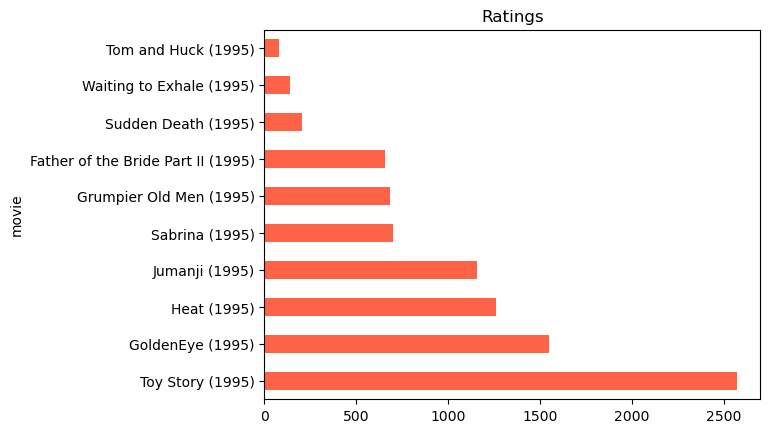

In [60]:
movies['movie'].value_counts().plot(kind='barh',title='Ratings',color='Tomato')

In [66]:
movies['rating'].value_counts()

rating
3.0    2736
4.0    2660
5.0    1394
3.5     679
2.0     542
4.5     374
2.5     277
1.0     212
1.5      61
0.5      57
Name: count, dtype: int64

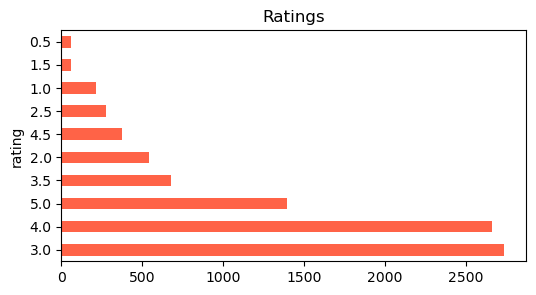

In [76]:
movies['rating'].value_counts().plot(kind='barh',title='Ratings',color='Tomato',figsize=(6,3))
plt.show()

In [78]:
grp=movies.groupby('movie')
grp.agg('mean') # it iwll give the mean for all numerical columsns

,userId,rating
movie,,
Father of the Bride Part II (1995),3418.366819,3.143836
GoldenEye (1995),3500.766150,3.427003
Grumpier Old Men (1995),3580.858394,3.186861
Heat (1995),3541.284127,3.836508
Jumanji (1995),3520.225974,3.268398
Sabrina (1995),3577.260000,3.381429
Sudden Death (1995),3351.485149,3.017327
Tom and Huck (1995),3292.884615,3.352564
Toy Story (1995),3528.748151,3.959323


In [88]:
(grp.agg('mean')['rating']).sort_values(ascending=False)

movie
Toy Story (1995)                      3.959323
Heat (1995)                           3.836508
GoldenEye (1995)                      3.427003
Sabrina (1995)                        3.381429
Tom and Huck (1995)                   3.352564
Jumanji (1995)                        3.268398
Grumpier Old Men (1995)               3.186861
Father of the Bride Part II (1995)    3.143836
Sudden Death (1995)                   3.017327
Waiting to Exhale (1995)              3.000000
Name: rating, dtype: float64

# Step 1 )Plot User vs item matrix

In [ ]:
# Get the user,movies,rating matrix

In [114]:
movies_user_mat=pd.pivot(movies,columns='movie',index='userId',values='rating')
movies_user_mat

movie,Father of the Bride Part II (1995),GoldenEye (1995),Grumpier Old Men (1995),Heat (1995),Jumanji (1995),Sabrina (1995),Sudden Death (1995),Tom and Huck (1995),Toy Story (1995),Waiting to Exhale (1995)
userId,,,,,,,,,,
1,NaN,NaN,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
4,NaN,4.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
7115,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7116,3.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
7117,NaN,3.0,4.0,5.0,NaN,3.0,1.0,NaN,4.0,NaN


# Step 2) fill sparse matrix using some methods

- As the above amtrix sparse, lets fill the null values

In [123]:
movies_user_mat.fillna(0,inplace=True)
movies_user_mat

movie,Father of the Bride Part II (1995),GoldenEye (1995),Grumpier Old Men (1995),Heat (1995),Jumanji (1995),Sabrina (1995),Sudden Death (1995),Tom and Huck (1995),Toy Story (1995),Waiting to Exhale (1995)
userId,,,,,,,,,,
1,0.0,0.0,0.0,0.0,3.5,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
4,0.0,4.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
7115,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7116,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
7117,0.0,3.0,4.0,5.0,0.0,3.0,1.0,0.0,4.0,0.0


# Step 3) create user-user similarity matrix with cosine values

# USER - USER similarity matrix

In [127]:
from sklearn.metrics.pairwise import cosine_similarity

In [131]:
user_sim_mat=cosine_similarity(movies_user_mat)
user_sim_mat

array([[1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.55337157],
       [0.        , 1.        , 0.        , ..., 0.45883147, 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.45883147, 1.        ,
        0.62254302],
       ...,
       [0.        , 0.45883147, 0.45883147, ..., 1.        , 0.45883147,
        0.47607054],
       [0.        , 0.        , 1.        , ..., 0.45883147, 1.        ,
        0.62254302],
       [0.55337157, 0.        , 0.62254302, ..., 0.47607054, 0.62254302,
        1.        ]])

- lets replace the diagonal values as it does not make any sense. which shows a similarity between same user.

In [134]:
import numpy as np

In [138]:
np.fill_diagonal(user_sim_mat,0)
user_sim_mat

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.55337157],
       [0.        , 0.        , 0.        , ..., 0.45883147, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.45883147, 1.        ,
        0.62254302],
       ...,
       [0.        , 0.45883147, 0.45883147, ..., 0.        , 0.45883147,
        0.47607054],
       [0.        , 0.        , 1.        , ..., 0.45883147, 0.        ,
        0.62254302],
       [0.55337157, 0.        , 0.62254302, ..., 0.47607054, 0.62254302,
        0.        ]])

- lets create the dataframe for above array

In [147]:
user_sim_df=pd.DataFrame(user_sim_mat,columns=movies['userId'].unique(),index=movies['userId'].unique())
user_sim_df

,3,6,8,10,11,12,13,14,16,19,...,6975,6979,6993,7030,7031,7044,7070,7080,7087,7105
3,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.707107,0.000000,0.000000,0.000000,0.000000,0.000000,0.553372
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.390567,0.707107,0.615457,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.458831,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.650945,0.000000,0.492366,1.000000,0.874157,...,0.000000,1.000000,0.000000,0.707107,0.000000,0.000000,0.752577,0.458831,1.000000,0.622543
10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.615457,0.000000,0.388514,...,0.800000,0.000000,0.000000,0.000000,0.989949,0.000000,0.000000,0.619422,0.000000,0.000000
11,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.707107,0.000000,0.000000,0.000000,0.000000,0.000000,0.553372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7044,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.658505,0.000000,0.000000,0.000000
7070,0.000000,0.000000,0.752577,0.000000,0.000000,0.489886,0.000000,0.370543,0.752577,0.657870,...,0.000000,0.752577,0.000000,0.532152,0.000000,0.658505,0.000000,0.345306,0.752577,0.468511
7080,0.000000,0.458831,0.458831,0.619422,0.000000,0.701884,0.567775,0.889532,0.458831,0.568212,...,0.344124,0.458831,0.000000,0.324443,0.648886,0.000000,0.345306,0.000000,0.458831,0.476071
7087,0.000000,0.000000,1.000000,0.000000,0.000000,0.650945,0.000000,0.492366,1.000000,0.874157,...,0.000000,1.000000,0.000000,0.707107,0.000000,0.000000,0.752577,0.458831,0.000000,0.622543


# Make recommondations

In [150]:
user=11

## Step 1 ) Find top 3 user very similar to 11

In [158]:
user_sim_df.loc[user] # this will give us similarity of all user with respect to user  11

3       1.000000
6       0.000000
8       0.000000
10      0.000000
11      0.000000
          ...   
7044    0.000000
7070    0.000000
7080    0.000000
7087    0.000000
7105    0.553372
Name: 11, Length: 4081, dtype: float64

In [162]:
user_sim_df.loc[user].sort_values(ascending=False)

3       1.0
497     1.0
743     1.0
703     1.0
698     1.0
       ... 
1003    0.0
1001    0.0
990     0.0
5014    0.0
5557    0.0
Name: 11, Length: 4081, dtype: float64

In [166]:
user_sim_df.loc[user].sort_values(ascending=False)[:3] # this will give us top 3 users which very similar to user 11

3      1.0
497    1.0
743    1.0
Name: 11, dtype: float64

In [173]:
sim_user_To_11=user_sim_df.loc[user].sort_values(ascending=False)[:3].index
sim_user_To_11

Index([3, 497, 743], dtype='int64')

## Step 2) Find higly rated movies by user which are very similar to user 11(i.e. user 3,497,743) 

In [182]:
sim_ratings=movies_user_mat.loc[sim_user_To_11]
sim_ratings

movie,Father of the Bride Part II (1995),GoldenEye (1995),Grumpier Old Men (1995),Heat (1995),Jumanji (1995),Sabrina (1995),Sudden Death (1995),Tom and Huck (1995),Toy Story (1995),Waiting to Exhale (1995)
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
497,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
743,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0


In [184]:
sim_ratings.values.argsort()# it will return respective index in ordered manner

array([[0, 1, 2, 3, 4, 5, 6, 7, 9, 8],
       [0, 1, 2, 4, 5, 6, 7, 8, 9, 3],
       [1, 2, 3, 5, 6, 7, 8, 9, 0, 4]], dtype=int64)

In [198]:
sim_ratings_idx=sim_ratings.values.argsort()[:,-1]
sim_ratings_idx

array([8, 3, 4], dtype=int64)

In [196]:
sim_ratings.columns

Index(['Father of the Bride Part II (1995)', 'GoldenEye (1995)',
       'Grumpier Old Men (1995)', 'Heat (1995)', 'Jumanji (1995)',
       'Sabrina (1995)', 'Sudden Death (1995)', 'Tom and Huck (1995)',
       'Toy Story (1995)', 'Waiting to Exhale (1995)'],
      dtype='object', name='movie')

In [200]:
sim_ratings.columns[sim_ratings_idx]

Index(['Toy Story (1995)', 'Heat (1995)', 'Jumanji (1995)'], dtype='object', name='movie')

## Step 3) Recommend movies to usr 11

In [204]:
print(f'recoomend movies {sim_ratings.columns[sim_ratings_idx].tolist()} to ser no {user}')

recoomend movies ['Toy Story (1995)', 'Heat (1995)', 'Jumanji (1995)'] to ser no 11


# B.item item similarity

In [212]:
user_movie_mat=movies_user_mat.T
user_movie_mat

userId,1,2,3,4,5,6,7,8,10,11,...,7105,7107,7108,7110,7113,7115,7116,7117,7119,7120
movie,,,,,,,,,,,,,,,,,,,,,
Father of the Bride Part II (1995),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,4.0,3.5,0.0,0.0,0.0
GoldenEye (1995),0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.5,...,2.0,0.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,0.0
Grumpier Old Men (1995),0.0,4.0,0.0,0.0,0.0,3.0,3.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0
Heat (1995),0.0,0.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,5.0,0.0,0.0
Jumanji (1995),3.5,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,4.0
Sabrina (1995),0.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,4.0
Sudden Death (1995),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Tom and Huck (1995),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Toy Story (1995),0.0,0.0,4.0,0.0,0.0,5.0,0.0,4.0,4.0,4.5,...,0.0,4.0,0.0,4.0,0.0,0.0,4.0,4.0,5.0,4.5


In [214]:
item_sim_mat=cosine_similarity(user_movie_mat)
item_sim_mat

array([[1.        , 0.21599275, 0.45566216, 0.24736744, 0.27980393,
        0.39574604, 0.22645759, 0.16293622, 0.30863759, 0.16378738],
       [0.21599275, 1.        , 0.21819777, 0.39773907, 0.40226034,
        0.22145469, 0.1552551 , 0.11972423, 0.38348625, 0.12844824],
       [0.45566216, 0.21819777, 1.        , 0.2901502 , 0.24471005,
        0.39017783, 0.25538652, 0.14395914, 0.31691062, 0.1564475 ],
       [0.24736744, 0.39773907, 0.2901502 , 1.        , 0.2800876 ,
        0.26207226, 0.25562862, 0.06285821, 0.40011642, 0.12402064],
       [0.27980393, 0.40226034, 0.24471005, 0.2800876 , 1.        ,
        0.24667163, 0.14328579, 0.19637377, 0.40998238, 0.14767896],
       [0.39574604, 0.22145469, 0.39017783, 0.26207226, 0.24667163,
        1.        , 0.20155614, 0.16464129, 0.31043392, 0.1894145 ],
       [0.22645759, 0.1552551 , 0.25538652, 0.25562862, 0.14328579,
        0.20155614, 1.        , 0.09721338, 0.16679265, 0.15179972],
       [0.16293622, 0.11972423, 0.1439591

In [220]:
np.fill_diagonal(item_sim_mat,0)
item_sim_mat

array([[0.        , 0.21599275, 0.45566216, 0.24736744, 0.27980393,
        0.39574604, 0.22645759, 0.16293622, 0.30863759, 0.16378738],
       [0.21599275, 0.        , 0.21819777, 0.39773907, 0.40226034,
        0.22145469, 0.1552551 , 0.11972423, 0.38348625, 0.12844824],
       [0.45566216, 0.21819777, 0.        , 0.2901502 , 0.24471005,
        0.39017783, 0.25538652, 0.14395914, 0.31691062, 0.1564475 ],
       [0.24736744, 0.39773907, 0.2901502 , 0.        , 0.2800876 ,
        0.26207226, 0.25562862, 0.06285821, 0.40011642, 0.12402064],
       [0.27980393, 0.40226034, 0.24471005, 0.2800876 , 0.        ,
        0.24667163, 0.14328579, 0.19637377, 0.40998238, 0.14767896],
       [0.39574604, 0.22145469, 0.39017783, 0.26207226, 0.24667163,
        0.        , 0.20155614, 0.16464129, 0.31043392, 0.1894145 ],
       [0.22645759, 0.1552551 , 0.25538652, 0.25562862, 0.14328579,
        0.20155614, 0.        , 0.09721338, 0.16679265, 0.15179972],
       [0.16293622, 0.11972423, 0.1439591

In [224]:
item_sim_df=pd.DataFrame(item_sim_mat,columns=movies['movie'].unique(),index=movies['movie'].unique())
item_sim_df

,Toy Story (1995),Jumanji (1995),Grumpier Old Men (1995),Waiting to Exhale (1995),Father of the Bride Part II (1995),Heat (1995),Sabrina (1995),Tom and Huck (1995),Sudden Death (1995),GoldenEye (1995)
Toy Story (1995),0.000000,0.215993,0.455662,0.247367,0.279804,0.395746,0.226458,0.162936,0.308638,0.163787
Jumanji (1995),0.215993,0.000000,0.218198,0.397739,0.402260,0.221455,0.155255,0.119724,0.383486,0.128448
Grumpier Old Men (1995),0.455662,0.218198,0.000000,0.290150,0.244710,0.390178,0.255387,0.143959,0.316911,0.156447
Waiting to Exhale (1995),0.247367,0.397739,0.290150,0.000000,0.280088,0.262072,0.255629,0.062858,0.400116,0.124021
Father of the Bride Part II (1995),0.279804,0.402260,0.244710,0.280088,0.000000,0.246672,0.143286,0.196374,0.409982,0.147679
Heat (1995),0.395746,0.221455,0.390178,0.262072,0.246672,0.000000,0.201556,0.164641,0.310434,0.189415
Sabrina (1995),0.226458,0.155255,0.255387,0.255629,0.143286,0.201556,0.000000,0.097213,0.166793,0.151800
Tom and Huck (1995),0.162936,0.119724,0.143959,0.062858,0.196374,0.164641,0.097213,0.000000,0.095521,0.148723
Sudden Death (1995),0.308638,0.383486,0.316911,0.400116,0.409982,0.310434,0.166793,0.095521,0.000000,0.138524
GoldenEye (1995),0.163787,0.128448,0.156447,0.124021,0.147679,0.189415,0.151800,0.148723,0.138524,0.000000
